# 标注框可视化
根据 YOLO 格式标签文件，在图片上画出 person 的 bounding box。

In [1]:
import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
# ── 配置区 ──────────────────────────────────────────────────────────────────
# 改这里切换 train / val
SPLIT = "train"          # "train" 或 "val"
N_SHOW = 6               # 随机展示几张；设为 None 则展示全部
RANDOM_SEED = 42         # None = 每次不同
BOX_COLOR = (0, 255, 0)  # BGR 绿色
BOX_THICKNESS = 2
# ────────────────────────────────────────────────────────────────────────────

BASE = os.path.abspath(os.path.join(os.path.dirname(os.getcwd()), ""))
# 如果直接在项目根目录运行，把上面一行换成：
# BASE = os.path.abspath(".")

IMG_DIR   = os.path.join(BASE, "datasets", "images", SPLIT)
LABEL_DIR = os.path.join(BASE, "datasets", "labels", SPLIT)

print("IMG_DIR  :", IMG_DIR)
print("LABEL_DIR:", LABEL_DIR)

IMG_DIR  : c:\Users\26846\Desktop\保研相关\套磁\已回复\唐敏——浙江大学\第一届浙江省大学生人工智能竞赛\train-yolo-v5\datasets\images\train
LABEL_DIR: c:\Users\26846\Desktop\保研相关\套磁\已回复\唐敏——浙江大学\第一届浙江省大学生人工智能竞赛\train-yolo-v5\datasets\labels\train


In [3]:
def load_boxes(label_path):
    """读取 YOLO 标签文件，返回 list of (cls, cx, cy, w, h)，坐标已归一化。"""
    boxes = []
    if not os.path.exists(label_path):
        return boxes
    with open(label_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls = int(float(parts[0]))
            cx, cy, bw, bh = map(float, parts[1:5])
            boxes.append((cls, cx, cy, bw, bh))
    return boxes


def draw_boxes(img_bgr, boxes):
    """在图片上画出所有框，返回带框的 RGB 图片（用于 matplotlib 显示）。"""
    img = img_bgr.copy()
    h, w = img.shape[:2]
    for cls, cx, cy, bw, bh in boxes:
        x1 = int((cx - bw / 2) * w)
        y1 = int((cy - bh / 2) * h)
        x2 = int((cx + bw / 2) * w)
        y2 = int((cy + bh / 2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), BOX_COLOR, BOX_THICKNESS)
        cv2.putText(img, "person", (x1, max(y1 - 4, 0)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, BOX_COLOR, 1, cv2.LINE_AA)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [4]:
# 收集所有有标签的图片
all_imgs = sorted([
    f for f in os.listdir(IMG_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

paired = []  # (img_path, label_path, n_boxes)
for fname in all_imgs:
    stem = os.path.splitext(fname)[0]
    lbl = os.path.join(LABEL_DIR, stem + ".txt")
    boxes = load_boxes(lbl)
    if boxes:  # 只保留有标注的
        paired.append((os.path.join(IMG_DIR, fname), lbl, len(boxes)))

print(f"共找到 {len(paired)} 张带标注的图片")

# 随机抽样
if N_SHOW is not None and N_SHOW < len(paired):
    if RANDOM_SEED is not None:
        random.seed(RANDOM_SEED)
    samples = random.sample(paired, N_SHOW)
else:
    samples = paired

print(f"本次展示 {len(samples)} 张")

共找到 1550 张带标注的图片
本次展示 6 张


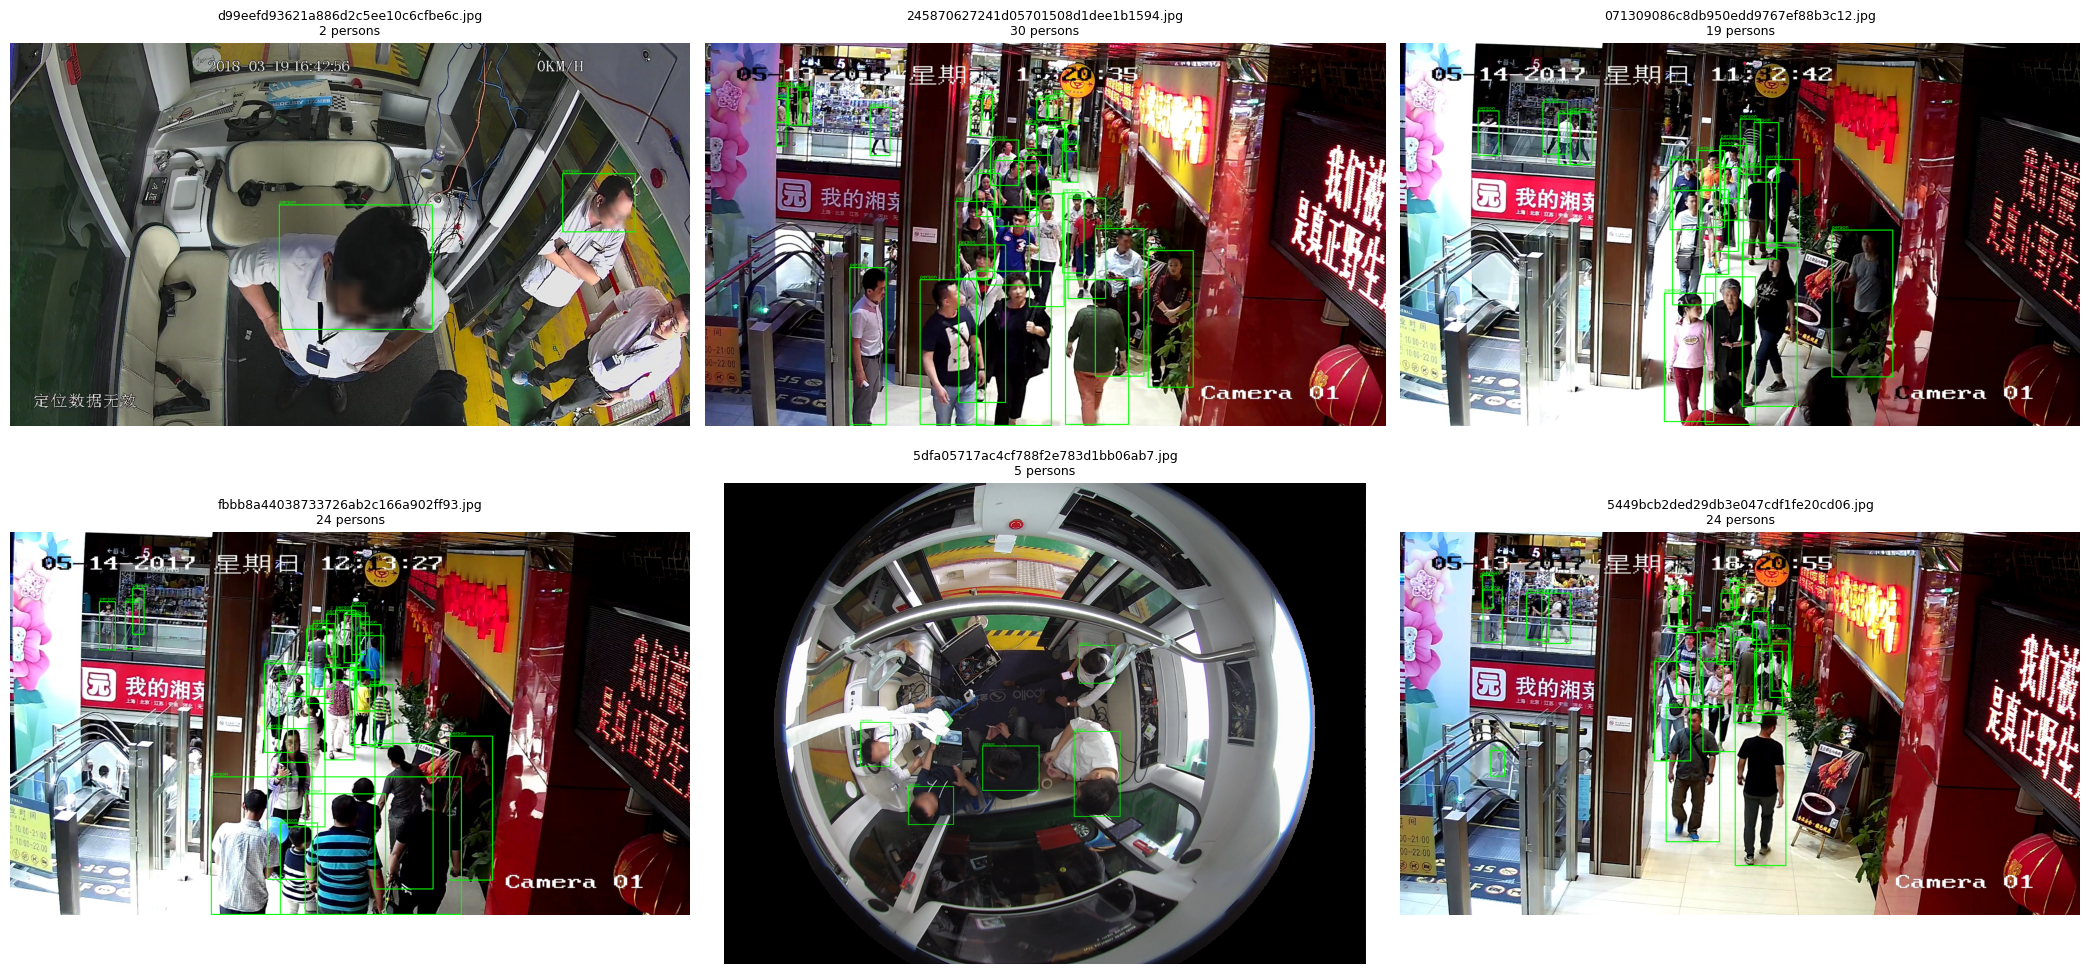

In [5]:
# 网格展示
cols = 3
rows = (len(samples) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 5 * rows))
axes = np.array(axes).reshape(-1)  # 展平方便索引

for i, (img_path, lbl_path, _) in enumerate(samples):
    img_bgr = cv2.imdecode(np.fromfile(img_path, dtype=np.uint8), cv2.IMREAD_COLOR)
    boxes = load_boxes(lbl_path)
    img_rgb = draw_boxes(img_bgr, boxes)

    ax = axes[i]
    ax.imshow(img_rgb)
    ax.set_title(f"{os.path.basename(img_path)}\n{len(boxes)} persons", fontsize=9)
    ax.axis("off")

# 隐藏多余的子图
for j in range(len(samples), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

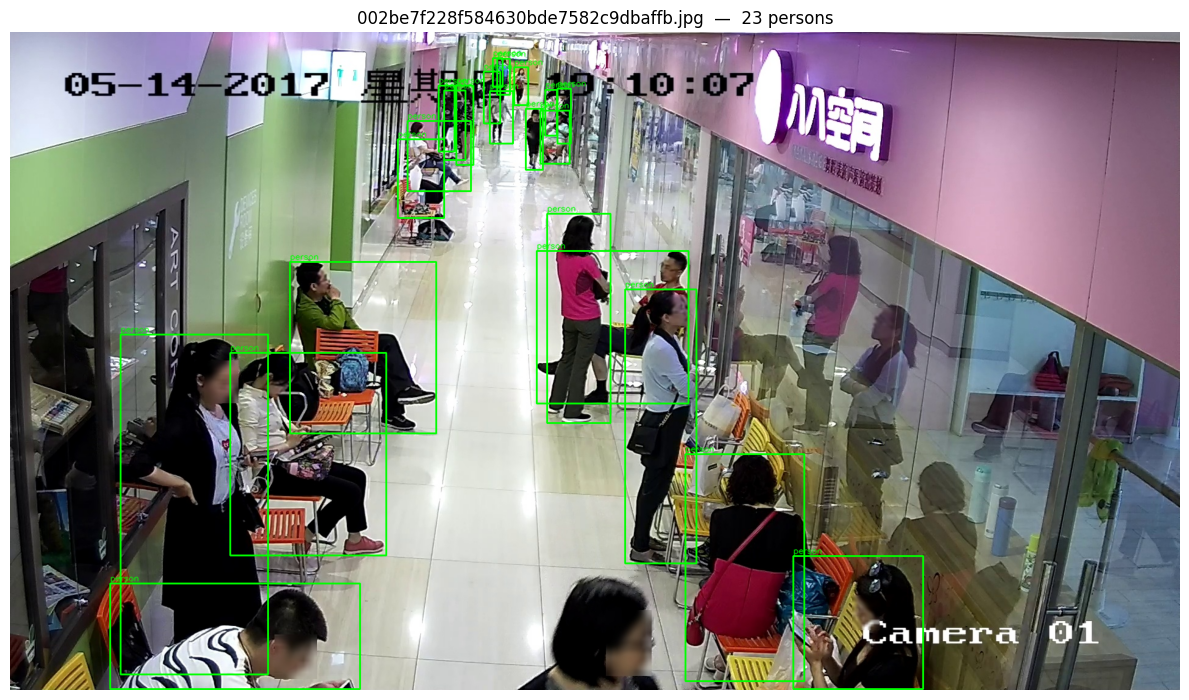

In [6]:
# ── 单张图片查看（指定文件名）────────────────────────────────────────────────
SINGLE_IMAGE = "002be7f228f584630bde7582c9dbaffb.jpg"  # 改成你想看的文件名

img_path  = os.path.join(IMG_DIR, SINGLE_IMAGE)
lbl_path  = os.path.join(LABEL_DIR, os.path.splitext(SINGLE_IMAGE)[0] + ".txt")
img_bgr   = cv2.imdecode(np.fromfile(img_path, dtype=np.uint8), cv2.IMREAD_COLOR)
boxes     = load_boxes(lbl_path)
img_rgb   = draw_boxes(img_bgr, boxes)

plt.figure(figsize=(12, 8))
plt.imshow(img_rgb)
plt.title(f"{SINGLE_IMAGE}  —  {len(boxes)} persons")
plt.axis("off")
plt.tight_layout()
plt.show()